<a href="https://colab.research.google.com/github/DCC-UAB/GABD_25_26_Practica_3/blob/master/src/insertGeonames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Passos previs


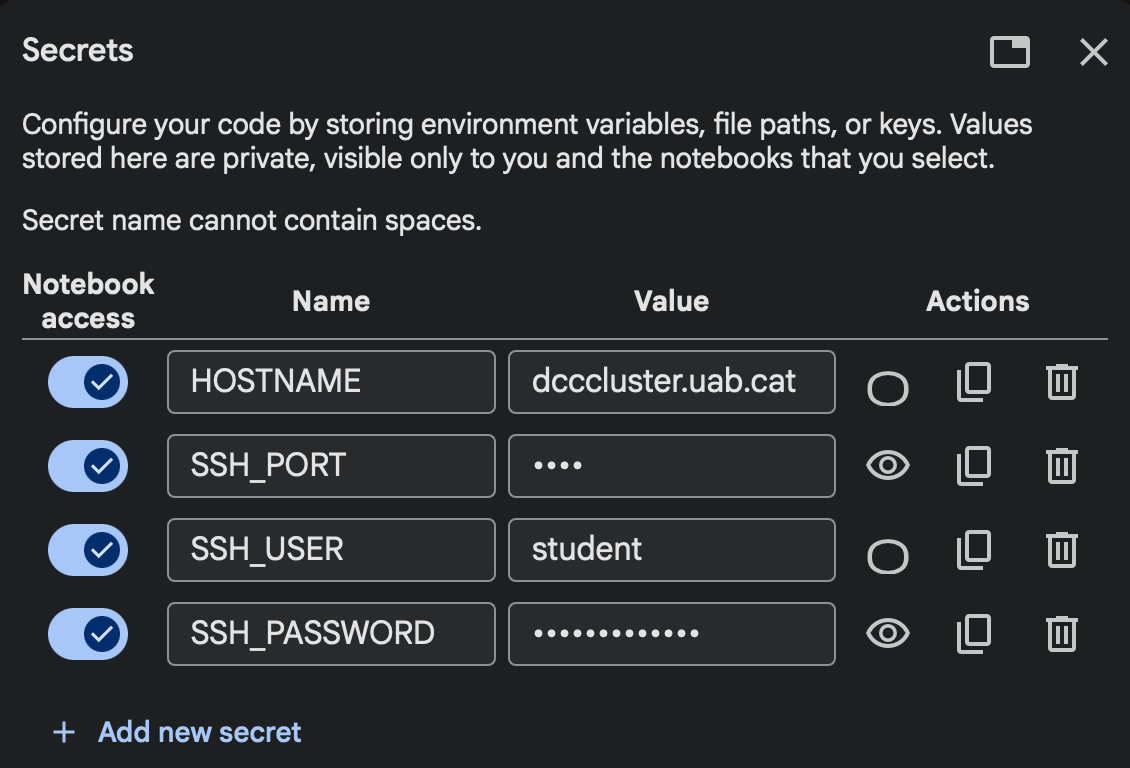

Primer s'han d'instal·lar els paquets de Python necessaris. A l'assignatura hem preparat el paquet __GABDConnect__ que instal·la aquestes dues dependències i us facilitarà la connexió a al infraestructura de càlcul. També s'ha d'instal·lar el paquet __geonames-lib__ per la importació de les dades de [geonames](https://www.geonames.org/). A més, a la secció de "Secrets" del Colab, haureu d'afegir les variables de les dades de connexió al servidor de MongoDB i del tunel de SSH privades del vostre grup per que pugueu obrir les connexions.



In [ ]:
# @title Install or Update GABDConnect Libraries

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Function to install required packages
def install_packages(b):
    """
    Function to install or update necessary Python packages.

    Parameters:
    - b: Button object. Click event handler.
    """
    clear_output(wait=True)
    !pip install --upgrade pip -q  # Upgrade pip silently
    !pip install  git+https://github.com/Oriolrt/GABDConnect@v3.2 ucimlrepo -q  # Install or upgrade GABDConnect silently
    !pip install html2text -q  # Install or upgrade html2text silently
    !pip install git+https://github.com/abmyii/geonames.git -q
    print("Libraries have been downloaded or updated.")

install_packages(True)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Libraries have been downloaded or updated.


In [ ]:
from GABDConnect import mongoConnection
from pymongo import errors

# Connexió a MongoDB
Inicialitzem les variables amb els valors guardats a la secció de "Secrets" com hem explicat a l'inici. La variable DSN conté les dades del __servidor__, __port__ i __bd_name__ necesaris per fer la connexió a MongoDB.


In [ ]:
import os
import logging

# Configurar el logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.WARNING)

# Crear un manejador de consola
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.WARNING)

# Crear un formatador i afegir-lo al manejador
formatter = logging.Formatter('%(levelname)s:%(message)s')
console_handler.setFormatter(formatter)

# Funció per detectar si s'està executant en Google Colab
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        from dotenv import load_dotenv
        load_dotenv() # Carrega el fitxer .env
        return False

if is_colab():
    from google.colab import userdata

    # Inicialitzem el diccionari amb les dades de connexió SSH per fer el túnel
    SSH_USER = userdata.get('SSH_USER')
    SSH_TUNNEL = userdata.get('HOSTNAME')

    SSH_PORT = userdata.get('SSH_PORT')
    SSH_PWD = userdata.get('SSH_PASSWORD')



else:
    # Inicialitzem el diccionari amb les dades de connexió SSH per fer el túnel
    SSH_USER = os.getenv('SSH_USER')
    SSH_TUNNEL = os.getenv('HOSTNAME')

    SSH_PORT = os.getenv('SSH_PORT')
    SSH_PWD = os.getenv('SSH_PASSWORD')


# Dades de connexió a MongoDB
grup = "grup22" # @param {type:str} Segons s'indica a l'enunciat de la pràctica
user = "gestorGeonames"           # @param {type:str} Segons s'indica a l'enunciat de la pràctica
bd_name = "Practica_3"    # @param {type:str} Nom de la base de dades de test
col_name = "geonames" #   @param {type:str} de la col·lecció de prova
port = 27017 # @param {type: int} port local del tunnel ssh

# Dades per fer el túnel SSH
ssh_server = {'ssh': SSH_TUNNEL, 'user': SSH_USER,
                  'pwd': SSH_PWD, 'port': SSH_PORT} if SSH_TUNNEL is not None else None

hostname=f"main.{grup}.gabd"
pwd = grup

# Exercici: Inserció de dades
Haureu d'acabar d'implementar la funció _insertGeonames_, la qual rebrà el _handler_ a la  **collection** on haureu d'inserir les dades de __GeoNames__.

In [ ]:
#@title
import urllib.request as request
import zipfile
import os
from tqdm import tqdm


def download_file(nameDataset):
  # Download US geonames dataset
  extract_to = os.getcwd()
  file_path = f"{extract_to}/{nameDataset}.txt"
  zip_path = os.path.join(extract_to, f'{nameDataset}.zip')
  url = f"http://download.geonames.org/export/dump/{nameDataset}.zip"
  if not os.path.exists(zip_path):
    request.urlretrieve(url, zip_path)
    print(f"Descarregat {zip_path}")
  else:
    print(f"El fitxer {file_path} ja s'ha descarregat.")

  # Descomprimir el fitxer zip
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
    print(f"Descomprimit a {extract_to}")

  return file_path

def insertBigFiles(collection,nameDataset, *args, **kwargs):
  # Adapted from https://stackoverflow.com/a/34499197
  columns = {
      'geonameid': float,
      'name': str,
      'asciiname': str,
      'alternatenames': str,
      'latitude': float,
      'longitude': float,
      'featureclass': str,
      'featurecode': str,
      'countrycode': str,
      'countrycode2': str,
      'admin1code': str,
      'admin2code': str,
      'admin3code': str,
      'admin4code': str,
      'population': float,
      'elevation': float,
      'dem': float,  # dem (digital elevation model)
      'timezone': str,
      'modificationdate': str
  }
  col.create_index([("geonameid", HASHED)], name="geonameid", sparse= True)
  fileName = kwargs['fileName']

  try:
    with tqdm(total=os.path.getsize(fileName)) as pbar:
      pbar.set_description(nameDataset)
      with open(fileName,'r') as fp:
        for line in fp:
          pbar.update(len(line))
          line = line.split('\t')
          doc = {k: v for k, v in zip(columns, line) if len(v) > 0}
          doc['location'] = {'type': "Point", 'coordinates': [float(doc['longitude']), float(doc['latitude'])]}
          doc.pop('longitude', None)
          doc.pop('latitude', None)
          if 'elevation' in doc:
            doc["elevation"] = int(doc["elevation"])
          if 'geonameid' in doc:
            doc["geonameid"] = int(doc["geonameid"])
            doc["_id"] = doc["geonameid"]

          if "modification date" in doc:
            doc["modification date"] = datetime.strptime(doc["modification date"].strip('\n'), '%Y-%m-%d')

          res = col.delete_one({'geonameid': doc['geonameid']})
          doc.pop('geonameid')

          res = col.update_one({'_id': doc['_id']},{ "$set" : doc },upsert=True)

    return True
  except Exception as e:
    print(e)
    return False



In [ ]:
from  geonames import GeoNames
import urllib.request as request
import zipfile
import math
import os
from pymongo import HASHED
from datetime import datetime

from geonames import GeoNames
import urllib.request as request
import zipfile
import math
import os
from pymongo import HASHED
from datetime import datetime


def insertGeonames(collection, nameDataset, *args, **kwargs):
    """
    Inserts the contents stored in the specified dataset into the MongoDB collection.

    Parameters:
    :param collection: handle to the MongoDB collection where data will be inserted.
    :param nameDataset: name of the dataset to be inserted into the database.
    :param args: additional positional arguments.
    :param kwargs: additional keyword arguments.
    :return: Boolean value indicating whether the data have been properly inserted into the database.
    """

    file_path = download_file(nameDataset)

    if nameDataset == "allCountries":
        return insertBigFiles(collection, nameDataset, fileName=file_path)

    # Load data
    print(f"Carregant les dades de {nameDataset} a Geonames ")
    with open(file_path, 'r', encoding='utf-8') as file:
        geo = GeoNames(file).data

    inserted_count = 0

    for index, row in geo.iterrows():  # Eliminado el .head(10)
        row_dict = row.to_dict()
        # Assignar el camp geonameid com a _id
        row_dict['_id'] = int(row_dict.pop('geonameid'))
        # neteja els valors nan
        row_dict = {k: v for k, v in row_dict.items() if not (isinstance(v, str) and v.lower() == 'nan')}
        row_dict = {k: v for k, v in row_dict.items() if not (isinstance(v, str) and v.lower() == '')}
        row_dict = {k: v for k, v in row_dict.items() if not (isinstance(v, float) and math.isnan(v))}

        # Convertir campos numéricos
        for key in ['latitude', 'longitude', 'population', 'elevation', 'dem']:
            if key in row_dict and row_dict[key]:
                try:
                    row_dict[key] = float(row_dict[key])
                except:
                    row_dict[key] = None

        # Inserir el diccionari a MongoDB
        # Usando upsert para insertar o actualizar
        try:
            result = collection.update_one(
                {'_id': row_dict['_id']},
                {'$set': row_dict},
                upsert=True
            )
            inserted_count += 1

            if inserted_count % 1000 == 0:
                print(f"Insertats {inserted_count} registres...")

        except Exception as e:
            print(f"Error inserint document _id={row_dict['_id']}: {e}")
            continue

    return True



# Carrega de dades

Les següents cel·les de codi s'encarreguen d'executar el cos principal (__main__) de codi. Essencialment no haureu de fer res excepte si voleu canviar el conjunt de dades de Geonames  a inserir:

```python
["US", "ES", "allCountries", "cities1500"]
```

Si voleu inserir altres conjunt de dades, o inserir-ne menys mentre feu proves, haureu de canviar aquesta llista.


In [ ]:
name="ES" # @param {type:str} ["US", "ES", "allCountries", "cities1500"]




In [ ]:
try:
  #TODO:
  # Recordeu crear el user amb el pwd que es demanaa a la pràctica
  with mongoConnection(user=user, pwd=pwd, hostname=hostname,
                          ssh_data=ssh_server, db=bd_name,
                          port=port) as client:

    bd = client.conn[bd_name]
    # creeem una col·lecció si no existeix
    try:
      col = bd[col_name]
    except:
      col = bd.create_collection(col_name)

    res = insertGeonames(col, name )

    if res:
      logging.warning(f"Dades a {name} carregades correctament.")
    else:
      logging.warning(f"Les Dades a {name} no s'han inserit correctament.")

except errors.OperationFailure as e:
  logging.warning(f"La connexió ha fallat: {e}. Recordeu crear l'usuari {user} \
    que es demana a l'enunciat de la pràctica.")





[INFO] Connexió SSH oberta a dcccluster.uab.cat:8192 com student
ssh -L 40525:main.grup00.gabd:27017 student@dcccluster.uab.cat -p 8192
Descarregat /content/ES.zip
Descomprimit a /content
Carregant les dades de ES a Geonames 


S'ha d'inserir {'name': 'Rio Erges', 'asciiname': 'Rio Erges', 'alternatenames': 'Elja River,Ribeira Erges,Ribeira de Erjes,Ribera de Erjas,Rio Elga,Rio Eljas,Rio Erges,Rio Erjas,Rio Erjes,Rivera de Erjas,Río Elga,Río Eljas,Río Erjas', 'latitude': 39.66667, 'longitude': -7.01667, 'featureclass': 'H', 'featurecode': 'STM', 'countrycode': 'ES', 'admin1code': '00', 'population': 0.0, 'dem': 252.0, 'timezone': 'Europe/Lisbon', 'modificationdate': '2023-11-07', '_id': 2268564}
S'ha d'inserir {'name': 'Rio Caia', 'asciiname': 'Rio Caia', 'alternatenames': 'Caia River,Ribeira do Caia,Rio Caia,Rio Caya,Río Caya', 'latitude': 38.83333, 'longitude': -7.08333, 'featureclass': 'H', 'featurecode': 'STM', 'countrycode': 'ES', 'admin1code': '00', 'population': 0.0, 'dem': 158.0, 'timezone': 'Europe/Lisbon', 'modificationdate': '2023-11-07', '_id': 2270458}
S'ha d'inserir {'name': 'Blackstrap Bay', 'asciiname': 'Blackstrap Bay', 'alternatenames': 'Blackstrap Bay,Mala Bahia,Mala Bahía', 'latitude': 36.

i tanquem la connexió.



